<a href="https://colab.research.google.com/github/ViaSr/ml-classification-breast-cancer/blob/main/LLMdemo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X = data.data        # 30 features (a DataFrame)
y = data.target      # labels: 0 = malignant, 1 = benign
print(X.shape)
print(data.target_names)   # ['malignant' 'benign']

(569, 30)
['malignant' 'benign']


In [2]:
df = data.frame
df.head()
df.describe()
y.value_counts()                       # class balance: how many of each?
y.value_counts(normalize=True)         # as proportions

,proportion
target,
1,0.627417
0,0.372583


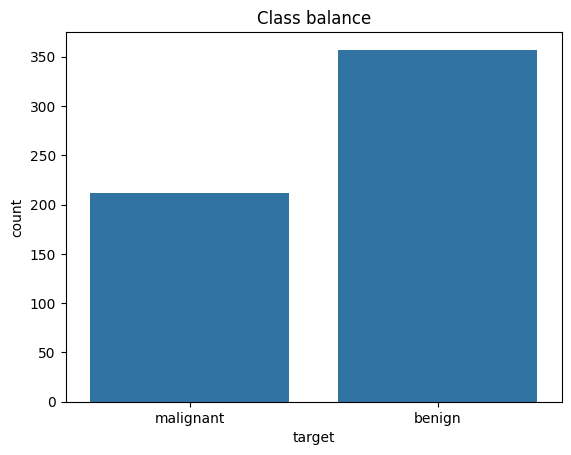

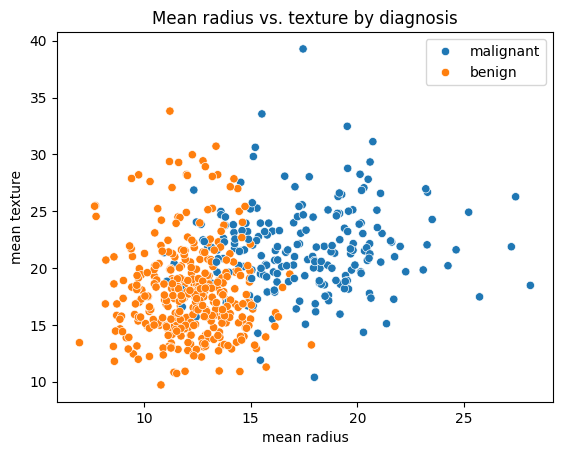

In [3]:
# Class balance
sns.countplot(x=y.map({0: 'malignant', 1: 'benign'}))
plt.title('Class balance'); plt.show()

# How two features separate the classes
sns.scatterplot(data=df, x='mean radius', y='mean texture',
                hue=data.target_names[y])
plt.title('Mean radius vs. texture by diagnosis'); plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(len(X_train), 'train /', len(X_test), 'test')

455 train / 114 test


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled  = scaler.transform(X_test)        # transform ONLY on test

In [6]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



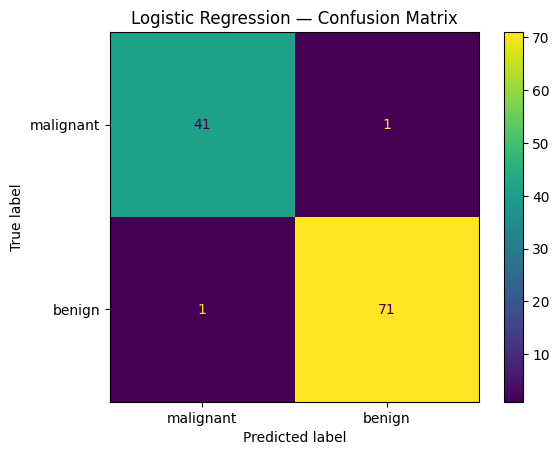

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred, target_names=data.target_names))

ConfusionMatrixDisplay.from_estimator(
    logreg, X_test_scaled, y_test, display_labels=data.target_names)
plt.title('Logistic Regression — Confusion Matrix'); plt.show()

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)              # note: RAW features, no scaling needed
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred, target_names=data.target_names))
print('RF train accuracy:', rf.score(X_train, y_train))
print('RF test  accuracy:', rf.score(X_test, y_test))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

RF train accuracy: 1.0
RF test  accuracy: 0.956140350877193


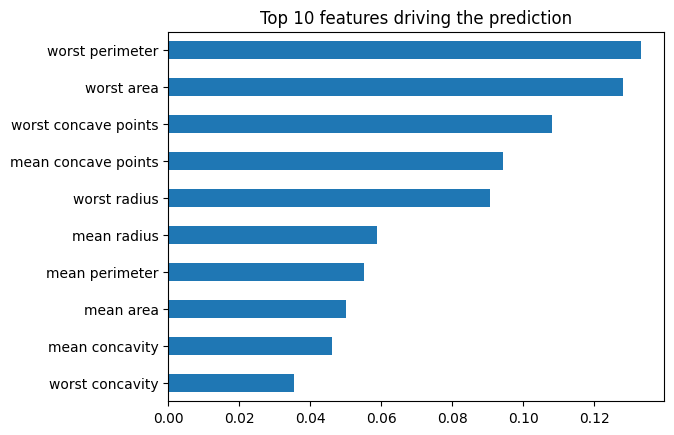

In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().tail(10).plot(kind='barh')
plt.title('Top 10 features driving the prediction'); plt.show()